# MSK Problem B - Multi-Model Training
## Myositis Classification: DM vs PM vs IBM

This notebook trains multiple deep learning models and compares their performance.

**Features:**
- ✅ Automatic checkpointing (survives crashes)
- ✅ Resume capability
- ✅ Progress saved to Google Drive

**Models tested:** ResNet50, ResNet101, EfficientNetB0, VGG16, DenseNet121

**Reference:** Burlina et al. 2017 (PLOS ONE) achieved 74.8% for IBM vs DM/PM

## Step 1: Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Set Your Paths
⚠️ **IMPORTANT:** Change `BASE_DIR` to match your Google Drive path!

In [2]:
import os

# ⚠️ CHANGE THIS TO YOUR DRIVE PATH
BASE_DIR = "/content/drive/MyDrive/MSK project"

EXCEL_PATH = os.path.join(BASE_DIR, "PatientImages_MATCHED.xlsx")
IMG_DIR = os.path.join(BASE_DIR, "processed_images")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Verify paths exist
print("Checking paths...")
print(f"  Base dir exists: {os.path.exists(BASE_DIR)}")
print(f"  Excel file exists: {os.path.exists(EXCEL_PATH)}")
print(f"  Images dir exists: {os.path.exists(IMG_DIR)}")

if os.path.exists(IMG_DIR):
    imgs = os.listdir(IMG_DIR)
    print(f"  Number of images: {len(imgs)}")

Checking paths...
  Base dir exists: True
  Excel file exists: True
  Images dir exists: True
  Number of images: 3214


## Step 3: Import Libraries

In [3]:
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import pickle

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tensorflow.keras.applications import (
    ResNet50, ResNet101, EfficientNetB0, VGG16, DenseNet121
)
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported successfully!
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 4: Configuration

In [4]:
FILENAME_COL = "filename"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 1e-4

tf.random.set_seed(42)
np.random.seed(42)

MODEL_CONFIGS = {
    "ResNet50": {
        "base_model": ResNet50,
        "preprocess": resnet_preprocess,
        "unfreeze_layers": 50,
    },
    "ResNet101": {
        "base_model": ResNet101,
        "preprocess": resnet_preprocess,
        "unfreeze_layers": 80,
    },
    "EfficientNetB0": {
        "base_model": EfficientNetB0,
        "preprocess": effnet_preprocess,
        "unfreeze_layers": 100,
    },
    "VGG16": {
        "base_model": VGG16,
        "preprocess": vgg_preprocess,
        "unfreeze_layers": 8,
    },
    "DenseNet121": {
        "base_model": DenseNet121,
        "preprocess": densenet_preprocess,
        "unfreeze_layers": 100,
    }
}

# Progress tracking file
PROGRESS_FILE = os.path.join(CHECKPOINT_DIR, "training_progress.json")

print("✅ Configuration set!")

✅ Configuration set!


## Step 5: Checkpoint & Progress Functions 💾

In [5]:
def save_progress(completed_models, all_results):
    """Save training progress to disk."""
    progress = {
        "completed_models": completed_models,
        "results": all_results,
        "timestamp": datetime.now().isoformat()
    }
    with open(PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2)
    print(f"💾 Progress saved! Completed: {completed_models}")

def load_progress():
    """Load training progress from disk."""
    if os.path.exists(PROGRESS_FILE):
        with open(PROGRESS_FILE, 'r') as f:
            progress = json.load(f)
        print(f"📂 Found previous progress!")
        print(f"   Completed models: {progress['completed_models']}")
        print(f"   Last saved: {progress['timestamp']}")
        return progress['completed_models'], progress['results']
    return [], []

def get_remaining_models(all_models, completed):
    """Get list of models that still need training."""
    return [m for m in all_models if m not in completed]

def clear_progress():
    """Clear saved progress to start fresh."""
    if os.path.exists(PROGRESS_FILE):
        os.remove(PROGRESS_FILE)
        print("🗑️ Progress cleared!")
    else:
        print("No progress file found.")

print("✅ Checkpoint functions ready!")

✅ Checkpoint functions ready!


## Step 6: Load Data

In [6]:
def find_diagnosis_column(df):
    target = {"D", "P", "I", "N"}
    best_col, best_overlap = None, 0
    for c in df.columns:
        vals = set(df[c].astype(str).str.strip().dropna().unique())
        overlap = len(vals & target)
        if overlap > best_overlap:
            best_overlap, best_col = overlap, c
    return best_col

df = pd.read_excel(EXCEL_PATH)
diag_col = find_diagnosis_column(df)
print(f"✅ Diagnosis column: {diag_col}")

df[diag_col] = df[diag_col].astype(str).str.strip()
df[FILENAME_COL] = df[FILENAME_COL].astype(str).str.strip()
df = df[df[diag_col].isin(["D", "P", "I"])].copy()

CLASS_MAP = {"D": 0, "P": 1, "I": 2}
CLASS_NAMES = ["Dermatomyositis", "Polymyositis", "IBM"]
df["label"] = df[diag_col].map(CLASS_MAP).astype("int32")

print("\n📊 Class Distribution:")
for cls, name in zip(["D", "P", "I"], CLASS_NAMES):
    print(f"   {cls} ({name}): {(df[diag_col] == cls).sum()}")

✅ Diagnosis column: Diagnosis
D - Dermatomyositis
P - Polymyositis
I - IBM
N - normal

📊 Class Distribution:
   D (Dermatomyositis): 555
   P (Polymyositis): 552
   I (IBM): 794


## Step 7: Split Data

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print(f"📂 Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Class weights
cw = compute_class_weight("balanced", classes=np.unique(train_df["label"]), y=train_df["label"])
class_weight = dict(enumerate(cw))
print(f"⚖️ Class weights: {class_weight}")

📂 Train: 1330 | Val: 285 | Test: 286
⚖️ Class weights: {0: np.float64(1.1426116838487972), 1: np.float64(1.14853195164076), 2: np.float64(0.7973621103117506)}


## Step 8: Dataset Creation Functions

In [8]:
def create_dataset(df, preprocess_fn, shuffle=True):
    def load_image(filename, label):
        filename = filename.numpy().decode() if hasattr(filename, 'numpy') else filename.decode()
        path = os.path.join(IMG_DIR, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = np.stack([img] * 3, axis=-1).astype("float32")
        img = preprocess_fn(img)
        return img, np.int32(label)

    def tf_load(x, y):
        img, lbl = tf.numpy_function(load_image, [x, y], [tf.float32, tf.int32])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        lbl.set_shape(())
        return img, lbl

    ds = tf.data.Dataset.from_tensor_slices((df[FILENAME_COL].values, df["label"].values))
    ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Dataset functions ready!")

✅ Dataset functions ready!


## Step 9: Model Building Function

In [9]:
def get_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomContrast(0.1),
    ])

def build_model(model_name):
    config = MODEL_CONFIGS[model_name]
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = get_augmentation()(inputs)

    base = config["base_model"](weights="imagenet", include_top=False, input_tensor=x)

    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-config["unfreeze_layers"]:]:
        if not isinstance(layer, BatchNormalization):
            layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(512, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(LEARNING_RATE), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    trainable = sum(1 for l in base.layers if l.trainable)
    print(f"   Trainable: {trainable}/{len(base.layers)} layers")
    return model

print("✅ Model building function ready!")

✅ Model building function ready!


## Step 10: Training Function (with Checkpointing)

In [10]:
def train_single_model(model_name, epochs=EPOCHS):
    print(f"\n{'='*60}")
    print(f"🚀 TRAINING: {model_name}")
    print(f"{'='*60}")

    config = MODEL_CONFIGS[model_name]

    # Create datasets
    train_ds = create_dataset(train_df, config["preprocess"], shuffle=True)
    val_ds = create_dataset(val_df, config["preprocess"], shuffle=False)
    test_ds = create_dataset(test_df, config["preprocess"], shuffle=False)

    # Paths for saving
    model_checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}_checkpoint.keras")
    model_best_path = os.path.join(RESULTS_DIR, f"{model_name}_best.keras")
    log_path = os.path.join(RESULTS_DIR, f"{model_name}_log.csv")

    # Check if we can resume training
    initial_epoch = 0
    if os.path.exists(model_checkpoint_path):
        print(f"📂 Found checkpoint for {model_name}, resuming...")
        model = load_model(model_checkpoint_path)
        # Try to get the last epoch from log
        if os.path.exists(log_path):
            log_df = pd.read_csv(log_path)
            initial_epoch = len(log_df)
            print(f"   Resuming from epoch {initial_epoch}")
    else:
        model = build_model(model_name)

    # Callbacks with checkpointing
    callbacks = [
        # Save best model
        ModelCheckpoint(
            model_best_path,
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        # Save checkpoint every epoch (for crash recovery)
        ModelCheckpoint(
            model_checkpoint_path,
            save_freq='epoch',
            verbose=0
        ),
        EarlyStopping(
            monitor="val_accuracy",
            patience=15,
            mode="max",
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        CSVLogger(log_path, append=True)  # Append mode for resume
    ]

    # Train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        initial_epoch=initial_epoch,
        class_weight=class_weight,
        callbacks=callbacks
    )

    # Evaluate
    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Load full training history from CSV
    full_history = pd.read_csv(log_path)

    axes[0].plot(full_history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(full_history['val_accuracy'], label='Val', linewidth=2)
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(full_history['loss'], label='Train', linewidth=2)
    axes[1].plot(full_history['val_loss'], label='Val', linewidth=2)
    axes[1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=['DM', 'PM', 'IBM'], yticklabels=['DM', 'PM', 'IBM'])
    axes[2].set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('True')
    axes[2].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"{model_name}_results.png"), dpi=150, bbox_inches='tight')
    plt.show()

    results = {
        "model": model_name,
        "test_accuracy": float(test_acc),
        "f1_macro": float(f1),
        "best_val_acc": float(full_history['val_accuracy'].max()),
        "epochs_trained": len(full_history)
    }

    print(f"\n📊 {model_name} Results:")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   F1 Score (Macro): {f1:.4f}")
    print(f"   Best Val Accuracy: {results['best_val_acc']:.4f}")

    # Clean up checkpoint (training complete)
    if os.path.exists(model_checkpoint_path):
        os.remove(model_checkpoint_path)
        print(f"🗑️ Removed intermediate checkpoint")

    # Clear memory
    del model
    tf.keras.backend.clear_session()

    return results

print("✅ Training function with checkpointing ready!")

✅ Training function with checkpointing ready!


---
# 🚀 Run Experiments
Choose ONE of the options below:

## Option A: Quick Test (5 epochs)


🚀 TRAINING: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Trainable: 80/239 layers
Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3316 - loss: 1.6798
Epoch 1: val_accuracy improved from -inf to 0.31579, saving model to /content/drive/MyDrive/MSK project/results/EfficientNetB0_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 158s 343ms/step - accuracy: 0.3321 - loss: 1.6761 - val_accuracy: 0.3158 - val_loss: 1.0843 - learning_rate: 1.0000e-04
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4110 - loss: 1.3432
Epoch 2: val_accuracy did not improve from 0.31579
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 252ms/step - accuracy: 0.4109 - loss: 1.3430 - val_accuracy: 0.3088 - val_loss: 1.1109 - learning_rate: 1.0000e-04
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4334 - loss: 1.2467
Epoch 3: val_accuracy did not improve from 0.31579
42/42 ━━━━━━━━━━━━━━━━━━━━ 22s 242ms/step - accuracy: 0.4337 - loss: 1.2468 - val_accuracy: 0.3053 - val_

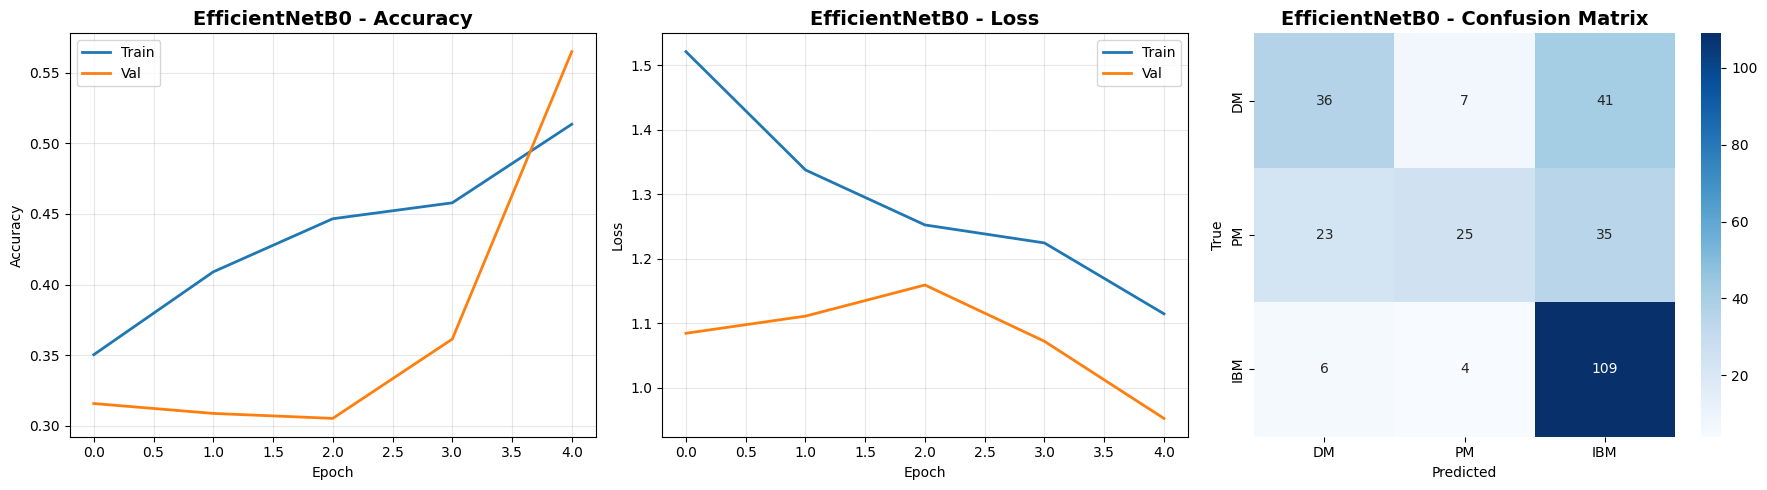


📊 EfficientNetB0 Results:
   Test Accuracy: 0.5944
   F1 Score (Macro): 0.5402
   Best Val Accuracy: 0.5649
🗑️ Removed intermediate checkpoint


In [11]:
quick_result = train_single_model("EfficientNetB0", epochs=5)

## Option B: Train ALL Models (with Auto-Resume) 🔥
⚠️ If server crashes, just re-run this cell - it will resume from where it left off!


📋 Models to train: ['ResNet50', 'ResNet101', 'EfficientNetB0', 'VGG16', 'DenseNet121']

🚀 TRAINING: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Trainable: 35/176 layers
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3904 - loss: 1.5370
Epoch 1: val_accuracy improved from -inf to 0.41754, saving model to /content/drive/MyDrive/MSK project/results/ResNet50_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 429ms/step - accuracy: 0.3907 - loss: 1.5342 - val_accuracy: 0.4175 - val_loss: 2.7580 - learning_rate: 1.0000e-04
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.3835 - loss: 1.3216
Epoch 2: val_accuracy did not improve from 0.41754
42/42 ━━━━━━━━━━━━━━━━━━━━ 24s 320ms/step - accuracy: 0.3839 - loss: 1.3205 - val_accuracy: 0.2912 - val_loss: 13.0436 - learning_rate: 1.0000e-04
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.4531 - loss: 1.2156
Epoch 3: val_accuracy did not improve from 0.41754
42/42 ━━━━━━━━━━━━━━━━━━━━

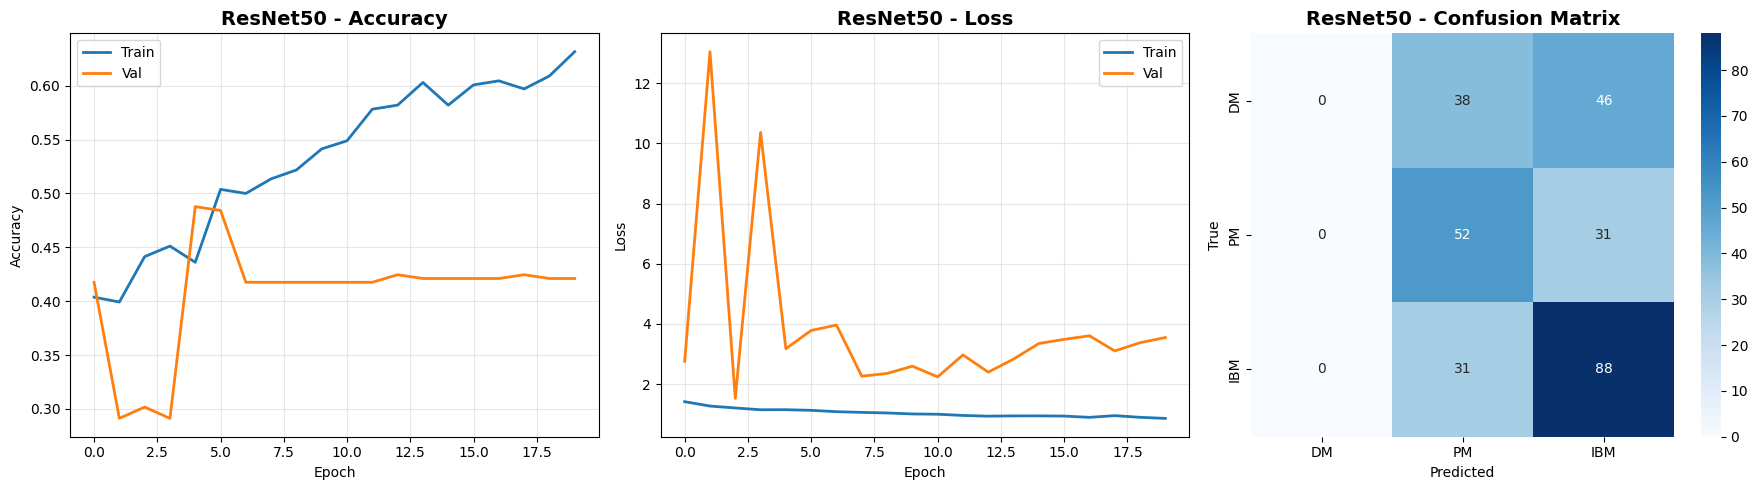


📊 ResNet50 Results:
   Test Accuracy: 0.4895
   F1 Score (Macro): 0.3765
   Best Val Accuracy: 0.4877
🗑️ Removed intermediate checkpoint
💾 Progress saved! Completed: ['ResNet50']

🚀 TRAINING: ResNet101
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   Trainable: 56/346 layers
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.3210 - loss: 1.6296
Epoch 1: val_accuracy improved from -inf to 0.36140, saving model to /content/drive/MyDrive/MSK project/results/ResNet101_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 55s 621ms/step - accuracy: 0.3215 - loss: 1.6260 - val_accuracy: 0.3614 - val_loss: 1.0847 - learning_rate: 1.0000e-04
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.3725 - loss: 1.3470
Epoch 2: val_accuracy improved from 0.36140 to 0.41754, saving model to /content/drive/MyDrive/MSK project/results/ResNet101_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 34s 546ms/step - accuracy: 0.3733 - loss: 1.3452 - val_accuracy: 0.4175 - val_loss: 4.1075 - learning_

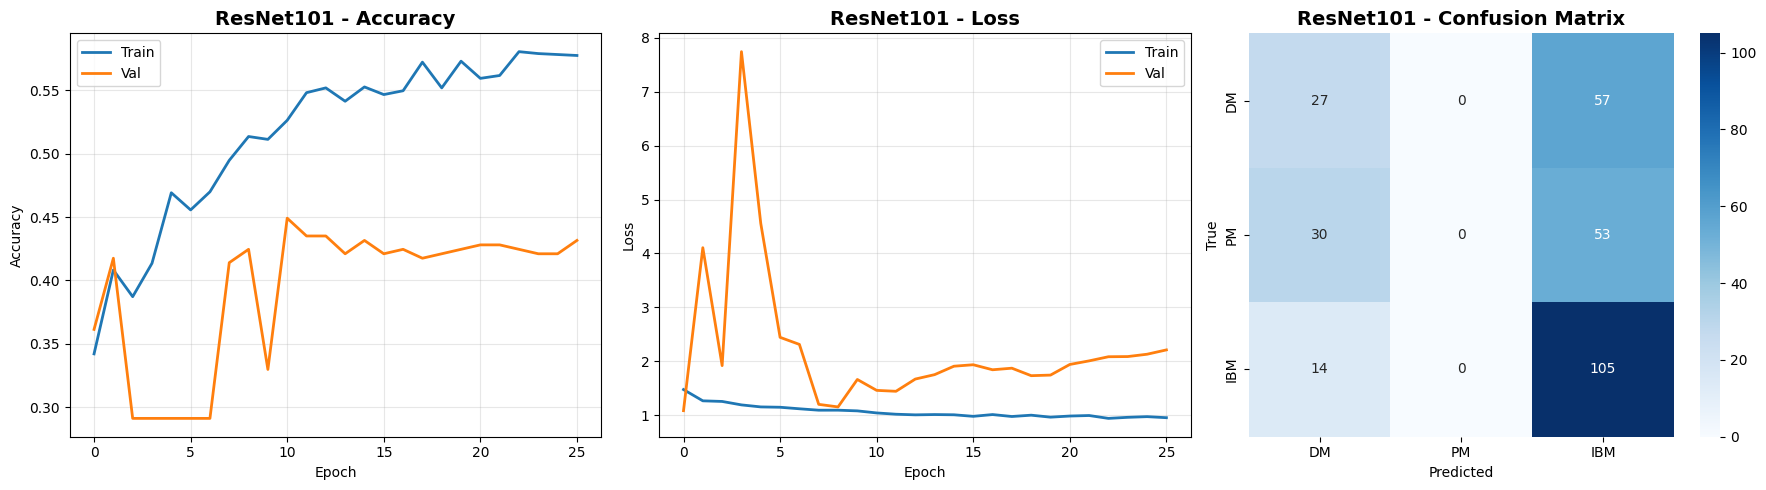


📊 ResNet101 Results:
   Test Accuracy: 0.4615
   F1 Score (Macro): 0.3257
   Best Val Accuracy: 0.4491
🗑️ Removed intermediate checkpoint
💾 Progress saved! Completed: ['ResNet50', 'ResNet101']

🚀 TRAINING: EfficientNetB0
   Trainable: 80/239 layers
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3339 - loss: 1.6559
Epoch 1: val_accuracy improved from -inf to 0.29123, saving model to /content/drive/MyDrive/MSK project/results/EfficientNetB0_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 332ms/step - accuracy: 0.3344 - loss: 1.6537 - val_accuracy: 0.2912 - val_loss: 1.1082 - learning_rate: 1.0000e-04
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.4134 - loss: 1.3652
Epoch 2: val_accuracy improved from 0.29123 to 0.29474, saving model to /content/drive/MyDrive/MSK project/results/EfficientNetB0_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 269ms/step - accuracy: 0.4137 - loss: 1.3636 - val_accuracy: 0.2947 - val_loss: 1.2243 - learning_rate: 1.0000e-04
Epoch 3

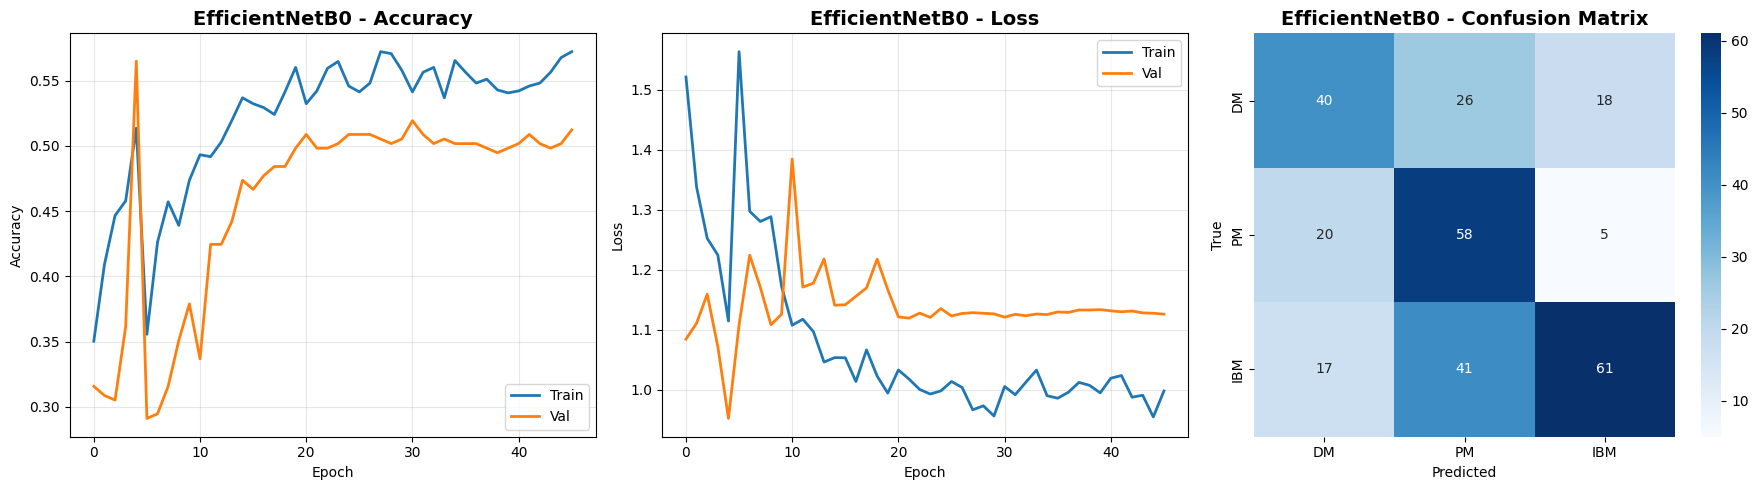


📊 EfficientNetB0 Results:
   Test Accuracy: 0.5559
   F1 Score (Macro): 0.5519
   Best Val Accuracy: 0.5649
🗑️ Removed intermediate checkpoint
💾 Progress saved! Completed: ['ResNet50', 'ResNet101', 'EfficientNetB0']

🚀 TRAINING: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Trainable: 8/20 layers
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.3471 - loss: 1.4330
Epoch 1: val_accuracy improved from -inf to 0.29123, saving model to /content/drive/MyDrive/MSK project/results/VGG16_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 540ms/step - accuracy: 0.3474 - loss: 1.4303 - val_accuracy: 0.2912 - val_loss: 12.6294 - learning_rate: 1.0000e-04
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.3320 - loss: 1.3274
Epoch 2: val_accuracy did not improve from 0.29123
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 307ms/step - accuracy: 0.3323 - loss: 1.3270 - val_accuracy: 0.2912 - val_loss: 46.2950 - learning_rate: 1.0000e-04
Epoch 3/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 

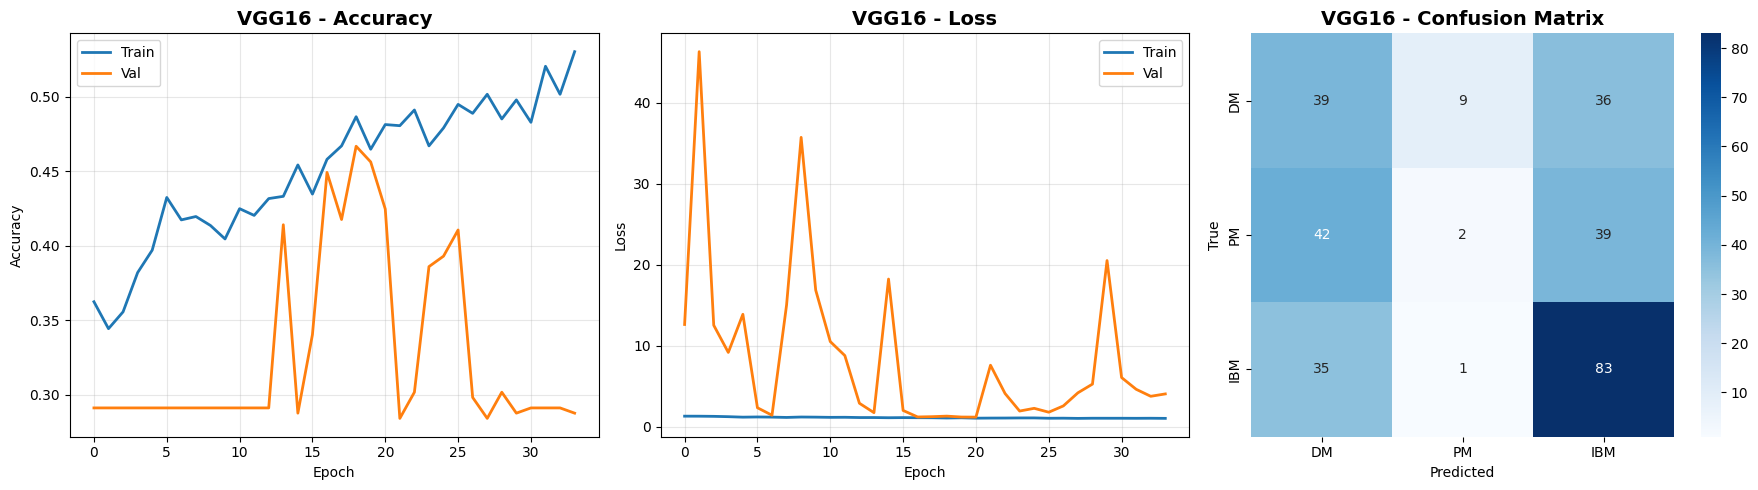


📊 VGG16 Results:
   Test Accuracy: 0.4336
   F1 Score (Macro): 0.3438
   Best Val Accuracy: 0.4667
🗑️ Removed intermediate checkpoint
💾 Progress saved! Completed: ['ResNet50', 'ResNet101', 'EfficientNetB0', 'VGG16']

🚀 TRAINING: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
   Trainable: 71/428 layers
Epoch 1/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.3189 - loss: 1.6090
Epoch 1: val_accuracy improved from -inf to 0.29474, saving model to /content/drive/MyDrive/MSK project/results/DenseNet121_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 488ms/step - accuracy: 0.3194 - loss: 1.6060 - val_accuracy: 0.2947 - val_loss: 1.1969 - learning_rate: 1.0000e-04
Epoch 2/50
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.3939 - loss: 1.3756
Epoch 2: val_accuracy improved from 0.29474 to 0.42456, saving model to /content/drive/MyDrive/MSK project/results/DenseNet121_best.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 23s 337ms/step - accuracy: 0.3945 - loss: 1.3746 - val_accura

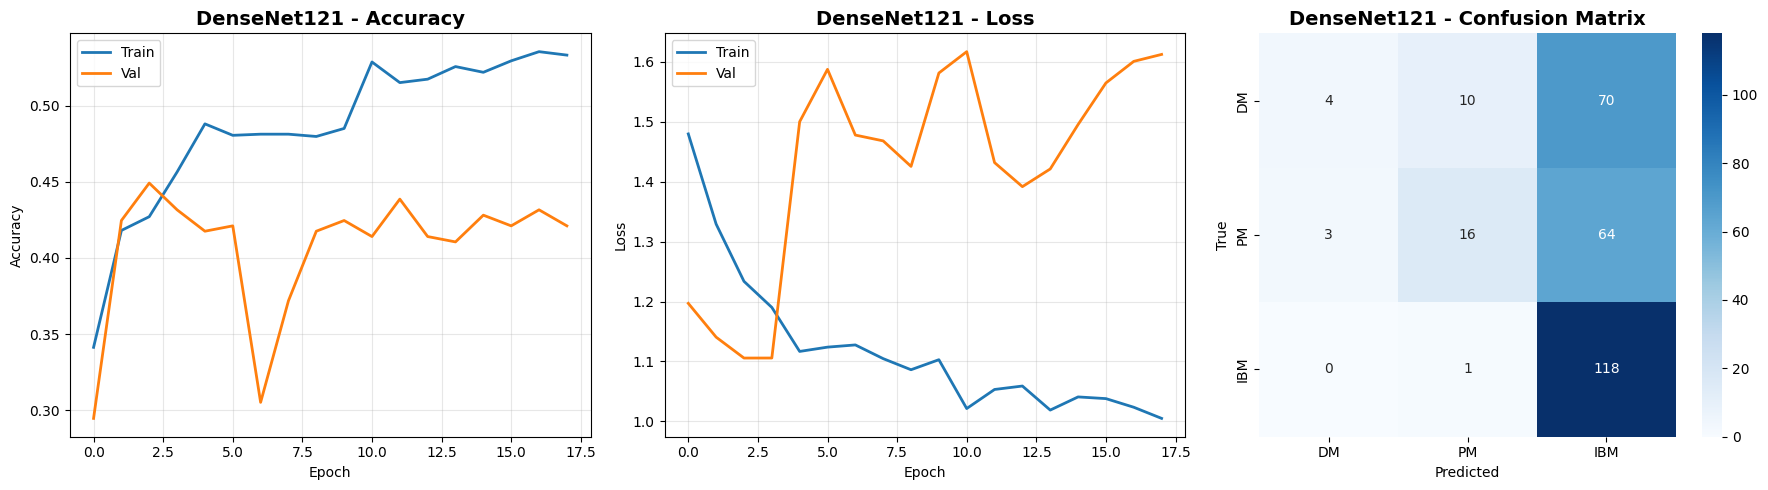


📊 DenseNet121 Results:
   Test Accuracy: 0.4825
   F1 Score (Macro): 0.3383
   Best Val Accuracy: 0.4491
🗑️ Removed intermediate checkpoint
💾 Progress saved! Completed: ['ResNet50', 'ResNet101', 'EfficientNetB0', 'VGG16', 'DenseNet121']

📊 FINAL COMPARISON
         model  test_accuracy  f1_macro  best_val_acc  epochs_trained
EfficientNetB0       0.555944  0.551857      0.564912              46
      ResNet50       0.489510  0.376507      0.487719              20
   DenseNet121       0.482517  0.338313      0.449123              18
     ResNet101       0.461538  0.325710      0.449123              26
         VGG16       0.433566  0.343794      0.466667              34

🏆 Best Model: EfficientNetB0 (Accuracy: 0.5559)


In [12]:
# Models to train
ALL_MODELS = ["ResNet50", "ResNet101", "EfficientNetB0", "VGG16", "DenseNet121"]

# Load previous progress (if any)
completed_models, all_results = load_progress()

# Get remaining models
remaining = get_remaining_models(ALL_MODELS, completed_models)

if not remaining:
    print("\n✅ All models already trained!")
else:
    print(f"\n📋 Models to train: {remaining}")

    for model_name in remaining:
        try:
            result = train_single_model(model_name, epochs=50)
            all_results.append(result)
            completed_models.append(model_name)

            # Save progress after each model
            save_progress(completed_models, all_results)

        except Exception as e:
            print(f"\n❌ Error training {model_name}: {str(e)}")
            save_progress(completed_models, all_results)
            raise  # Re-raise to see the full error

# Final comparison
if all_results:
    results_df = pd.DataFrame(all_results).sort_values("test_accuracy", ascending=False)
    print("\n" + "="*60)
    print("📊 FINAL COMPARISON")
    print("="*60)
    print(results_df.to_string(index=False))
    results_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"), index=False)

    # Find best
    best = results_df.iloc[0]
    print(f"\n🏆 Best Model: {best['model']} (Accuracy: {best['test_accuracy']:.4f})")

## Option C: Clear Progress (Start Fresh)

In [13]:
# Uncomment to clear progress and start fresh
# clear_progress()

## Option D: Train Individual Models

In [14]:
# ResNet50
# result_resnet50 = train_single_model("ResNet50", epochs=50)

In [15]:
# ResNet101
# result_resnet101 = train_single_model("ResNet101", epochs=50)

In [16]:
# EfficientNetB0
# result_effnet = train_single_model("EfficientNetB0", epochs=50)

In [17]:
# VGG16
# result_vgg = train_single_model("VGG16", epochs=50)

In [18]:
# DenseNet121
# result_densenet = train_single_model("DenseNet121", epochs=50)

---
## Generate Comparison Table Image

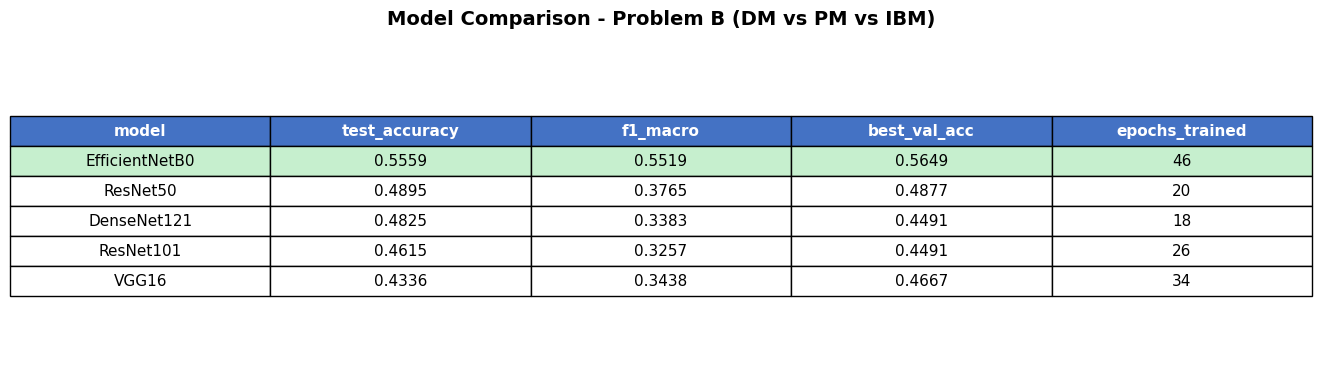

✅ Table saved to: /content/drive/MyDrive/MSK project/results/comparison_table.png


In [19]:
# Create visual comparison table
if os.path.exists(os.path.join(RESULTS_DIR, "model_comparison.csv")):
    comp_df = pd.read_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"))
    comp_df = comp_df.round(4)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(
        cellText=comp_df.values,
        colLabels=comp_df.columns,
        cellLoc='center',
        loc='center',
        colColours=['#4472C4'] * len(comp_df.columns)
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.8)

    for i in range(len(comp_df.columns)):
        table[(0, i)].set_text_props(color='white', fontweight='bold')

    for i in range(len(comp_df.columns)):
        table[(1, i)].set_facecolor('#C6EFCE')

    plt.title("Model Comparison - Problem B (DM vs PM vs IBM)", fontsize=14, fontweight='bold', pad=20)
    plt.savefig(os.path.join(RESULTS_DIR, "comparison_table.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Table saved to: {RESULTS_DIR}/comparison_table.png")
else:
    print("⚠️ No results found. Train models first!")

## Check Training Progress

In [20]:
# Check current progress
completed, results = load_progress()
print(f"\n📊 Training Status:")
print(f"   Completed: {len(completed)}/5 models")
print(f"   Remaining: {get_remaining_models(ALL_MODELS, completed)}")

📂 Found previous progress!
   Completed models: ['ResNet50', 'ResNet101', 'EfficientNetB0', 'VGG16', 'DenseNet121']
   Last saved: 2026-01-14T09:35:22.726248

📊 Training Status:
   Completed: 5/5 models
   Remaining: []
